In [ ]:
import pandas as pd

# Load dataset from CSV file
df = pd.read_csv(r"C:\Users\vansh\OneDrive\Desktop\mango\ml model\data\dataset_mango.csv")

# Show first 5 rows
print(df.head())

   Soil_Moisture    Nitrogen  Phosphorus   Potassium  Light_Density  \
0      36.217808  109.045328   43.627674  124.950537    7839.986488   
1      76.550001  121.015349   39.962089  162.012016    3476.095965   
2      61.239576  178.182109   25.853852  134.400017    4773.117555   
3      51.906094  101.000658   64.654000   62.495387    7306.245095   
4      20.921305  180.447453   52.896174   77.837036    5856.714756   

   Irrigation   Soil_pH        EC  Temperature   Humidity  Feasible  
0           1  8.387951  0.227513    25.087876  24.821228         0  
1           1  5.069196  0.455125    24.240409  30.579468         0  
2           1  8.065007  1.808164    19.059164  89.550052         1  
3           0  5.814838  0.346444    26.196167  80.983678         1  
4           0  4.550627  2.191715    17.451726  29.332919         0  


In [176]:
# Check basic info of dataset
print(df.info())

# Check statistical summary
print(df.describe())

# Check if any missing values exist
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Soil_Moisture  5000 non-null   float64
 1   Nitrogen       5000 non-null   float64
 2   Phosphorus     5000 non-null   float64
 3   Potassium      5000 non-null   float64
 4   Light_Density  5000 non-null   float64
 5   Irrigation     5000 non-null   int64  
 6   Soil_pH        5000 non-null   float64
 7   EC             5000 non-null   float64
 8   Temperature    5000 non-null   float64
 9   Humidity       5000 non-null   float64
 10  Feasible       5000 non-null   int64  
dtypes: float64(9), int64(2)
memory usage: 429.8 KB
None
       Soil_Moisture     Nitrogen   Phosphorus    Potassium  Light_Density  \
count    5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean       44.778239   123.723069    55.123755   126.152705    6070.216916   
std        20.274356    42.842

In [177]:
# ===================== ADVANCED NON-LINEAR TARGET =====================

import numpy as np

# Strong non-linear transformations
ph_effect = -((df['Soil_pH'] - 6.5) ** 2) * 3
temp_effect = np.sin(df['Temperature'] / 10) * 2
light_effect = np.log(df['Light_Density'] + 1)

# Threshold-based conditions (tree-friendly)
condition1 = (df['Soil_Moisture'] > 40).astype(int)
condition2 = (df['Nitrogen'] > 120).astype(int)
condition3 = (df['EC'] < 1.5).astype(int)
condition4 = (df['Humidity'] > 50).astype(int)

# Interaction (complex pattern)
interaction = (df['Soil_Moisture'] * df['Humidity']) / 100

# Final score
score = (
    ph_effect +
    temp_effect +
    0.02 * df['Nitrogen'] +
    0.02 * df['Phosphorus'] +
    0.02 * df['Potassium'] +
    0.5 * light_effect +
    0.03 * interaction +
    2 * condition1 +
    2 * condition2 +
    2 * condition3 +
    2 * condition4
)

# Add noise (IMPORTANT but controlled)
score += np.random.normal(0, 2, len(df))

# Convert to binary
threshold = np.percentile(score, 55)   # slightly harder boundary

df['Feasible'] = (score > threshold).astype(int)

# ===================== CHECK =====================
print(df['Feasible'].value_counts())

Feasible
0    2750
1    2250
Name: count, dtype: int64


In [178]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (input)
X = df.drop("Feasible", axis=1)

# Target (output)
y = df["Feasible"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data scaling done!")

Data scaling done!


In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

#precision aur recall k beech ka data 
#diff btwn how many model did actually say feasible and out of all feasible in how many he was right 
#f1=2 * (precision* recall)/(precision + recall)
print("F1 Score:", f1_score(y_test, y_pred))

Model Accuracy: 0.682
F1 Score: 0.625


In [180]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[417 148]
 [170 265]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.74      0.72       565
           1       0.64      0.61      0.62       435

    accuracy                           0.68      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.68      0.68      0.68      1000



In [181]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy*100)


# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy*100)

Decision Tree Accuracy: 77.9
Random Forest Accuracy: 83.6


In [182]:
from sklearn.metrics import f1_score

# Logistic Regression
print("Logistic F1:", f1_score(y_test, y_pred))

# Decision Tree
print("Decision Tree F1:", f1_score(y_test, dt_pred))

# Random Forest
print("Random Forest F1:", f1_score(y_test, rf_pred))

Logistic F1: 0.625
Decision Tree F1: 0.7445086705202312
Random Forest F1: 0.8042959427207638


In [183]:
import pandas as pd

print("Actual:\n", y_test.value_counts()) # 0 means not feasible 1 means feasible 
print("\nPredicted:\n", pd.Series(rf_pred).value_counts())

Actual:
 Feasible
0    565
1    435
Name: count, dtype: int64

Predicted:
 0    597
1    403
Name: count, dtype: int64


In [184]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred) #fn low, fp high
                                    #fp low , fn high
print(cm)

[[499  66]
 [ 98 337]]


In [185]:
conditions = (
    (df["Soil_Moisture"].between(25, 65)).astype(int) +
    (df["Nitrogen"].between(80, 220)).astype(int) +
    (df["Phosphorus"].between(15, 70)).astype(int) +
    (df["Potassium"].between(80, 220)).astype(int) +
    (df["Soil_pH"].between(5.0, 8.0)).astype(int) +
    (df["Temperature"].between(18, 38)).astype(int)
)

# If at least 4 conditions satisfied → Feasible
df["Feasible"] = (conditions >= 4).astype(int)

In [186]:
print(df["Feasible"].value_counts())

Feasible
1    3731
0    1269
Name: count, dtype: int64


In [187]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.836


In [188]:
from sklearn.model_selection import cross_val_score
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=25,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Train:", rf_model.score(X_train, y_train))
print("Test:", rf_model.score(X_test, y_test))
print("F1:", f1_score(y_test, rf_pred))


Train: 0.8885
Test: 0.829
F1: 0.7966706302021404


C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1720031082.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1720031082.py:48: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


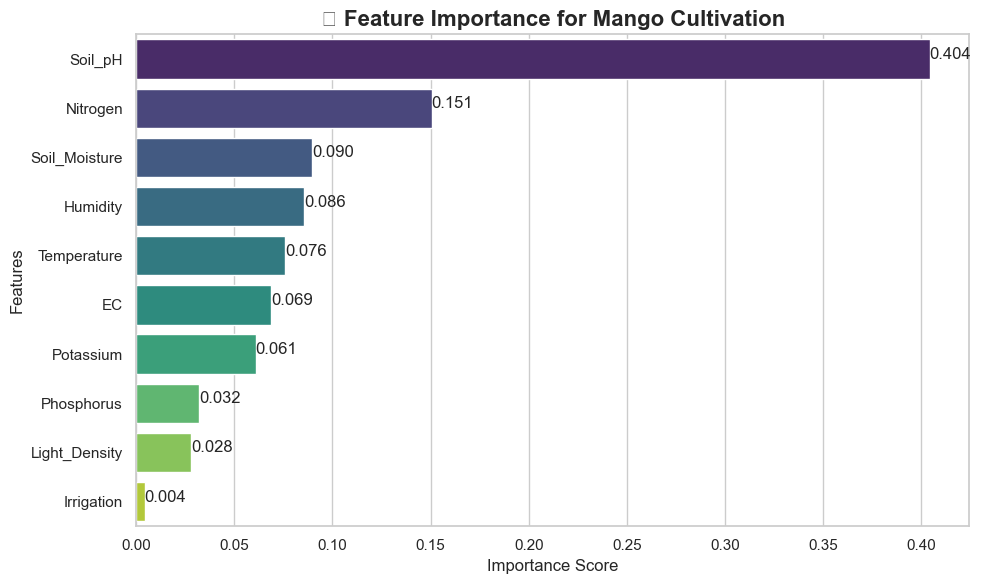

In [189]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
# ===================== 🌱 FEATURE IMPORTANCE (RANDOM FOREST) =====================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Convert to DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

plt.title("🌿 Feature Importance for Mango Cultivation", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Add values on bars
for index, value in enumerate(feature_importance_df['Importance']):
    plt.text(value, index, f"{value:.3f}")

plt.tight_layout()
plt.show()


# ===================== END =====================

In [190]:
from sklearn.model_selection import cross_val_score

print("----- OVERFITTING CHECK -----")

# Training score
train_score = rf_model.score(X_train, y_train)

# Test score
test_score = rf_model.score(X_test, y_test)

# Cross-validation score
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")

----- OVERFITTING CHECK -----
Train Accuracy: 0.9493
Test Accuracy: 0.8300
CV Mean Accuracy: 0.8480
CV Std Dev: 0.0099


C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:28: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


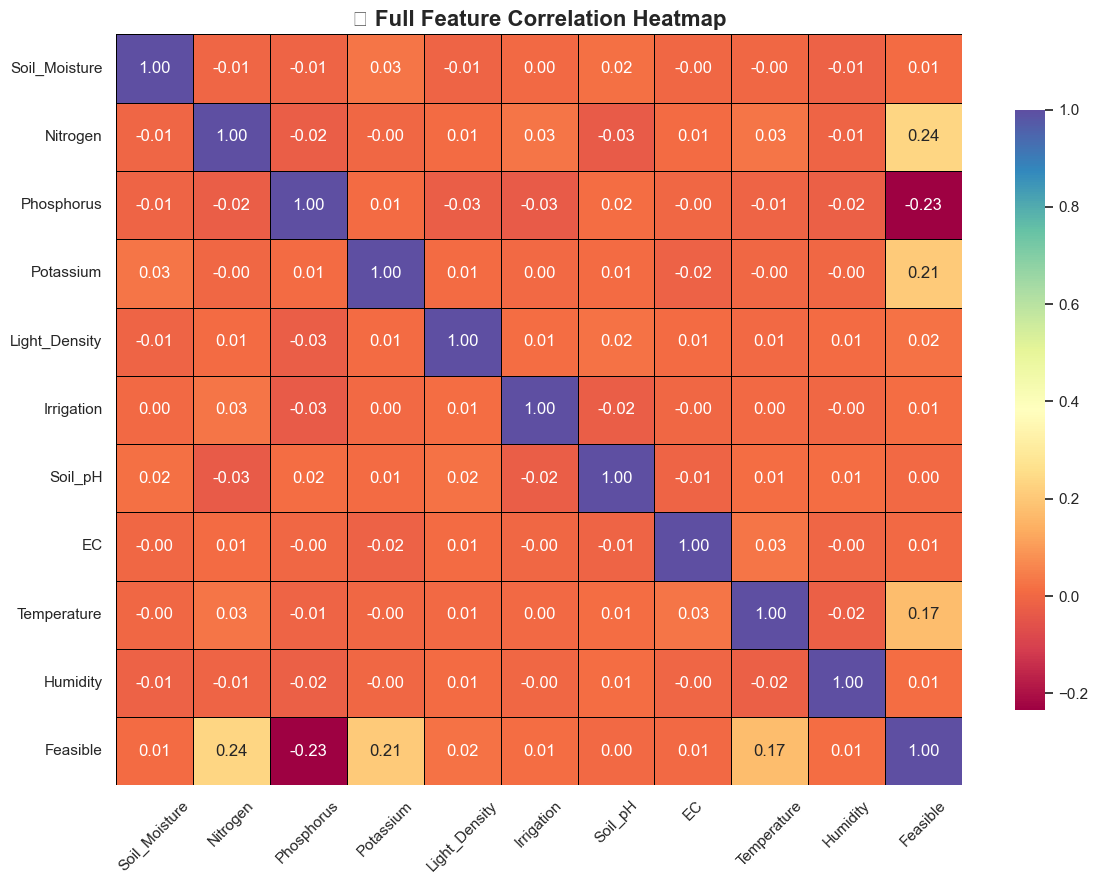

C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:47: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


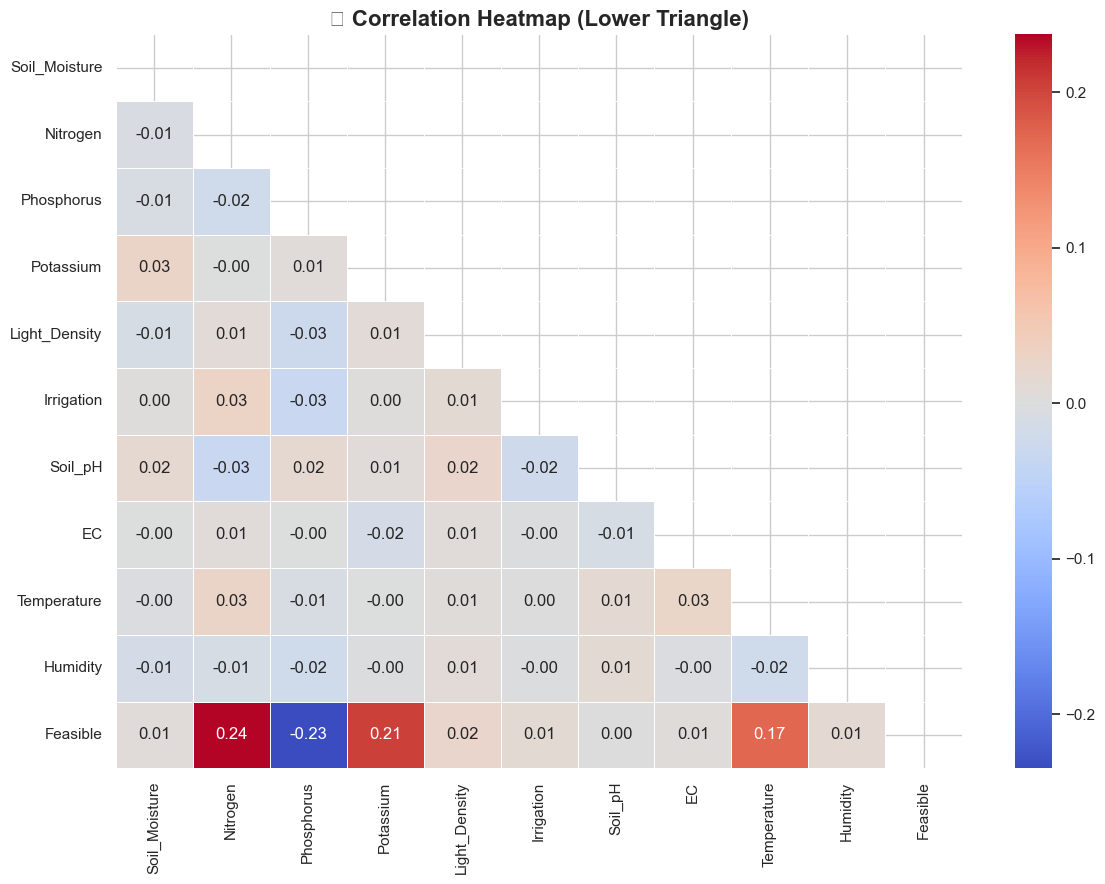

C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:64: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


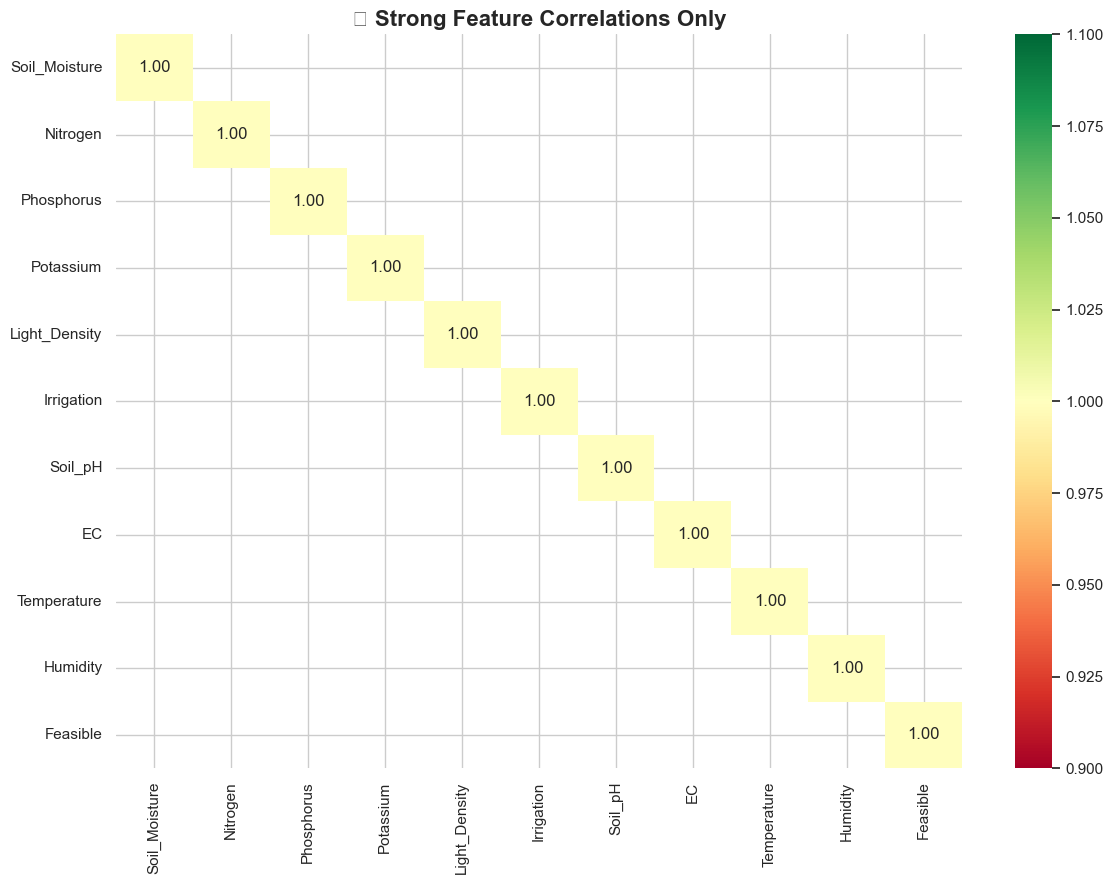

C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()


<Figure size 1400x1000 with 0 Axes>

C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


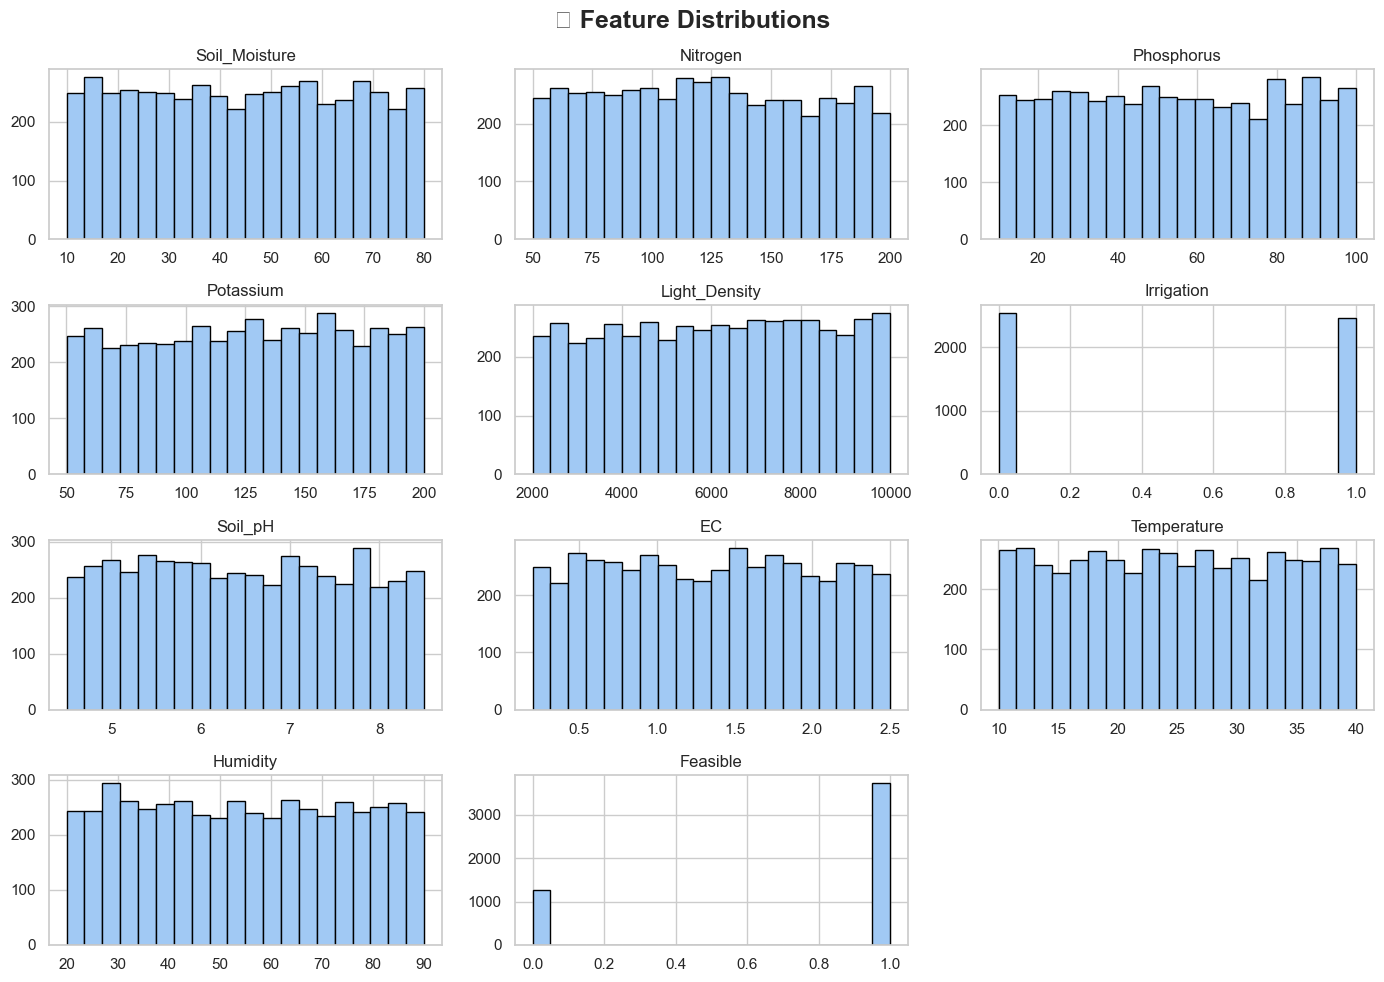

C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Feasible', data=df, palette='Set2')
C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1272962334.py:91: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


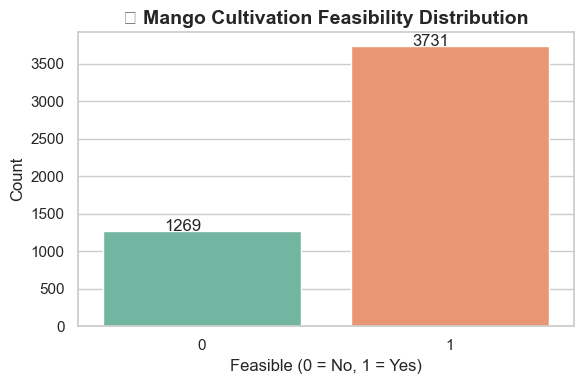

In [191]:
# ===================== 🌱 MANGO DATA VISUALIZATION (PRO LEVEL) =====================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Style setup (global)
sns.set_theme(style="whitegrid", palette="pastel")

# -------------------- 1. FULL CORRELATION HEATMAP --------------------
plt.figure(figsize=(12,9))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",   # vibrant colors
    fmt=".2f",
    linewidths=0.5,
    linecolor='black',
    cbar_kws={"shrink": 0.8}
)

plt.title("🌱 Full Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# -------------------- 2. TRIANGULAR HEATMAP (CLEAN LOOK) --------------------
plt.figure(figsize=(12,9))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("🌿 Correlation Heatmap (Lower Triangle)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# -------------------- 3. STRONG CORRELATION HEATMAP --------------------
plt.figure(figsize=(12,9))

strong_corr = corr[(corr > 0.5) | (corr < -0.5)]

sns.heatmap(
    strong_corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("🔥 Strong Feature Correlations Only", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# -------------------- 4. FEATURE DISTRIBUTION (VERY IMPORTANT) --------------------
plt.figure(figsize=(14,10))

df.hist(bins=20, figsize=(14,10), edgecolor='black')

plt.suptitle("📊 Feature Distributions", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


# -------------------- 5. TARGET CLASS DISTRIBUTION --------------------
plt.figure(figsize=(6,4))

sns.countplot(x='Feasible', data=df, palette='Set2')

plt.title("🎯 Mango Cultivation Feasibility Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Feasible (0 = No, 1 = Yes)")
plt.ylabel("Count")

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + 0.25, p.get_height() + 5))

plt.tight_layout()
plt.show()


# ===================== END =====================

C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\1854885870.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


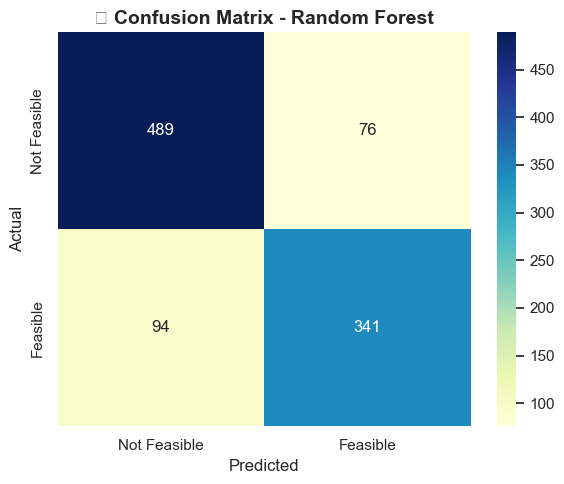

In [192]:
# ===================== 🎯 CONFUSION MATRIX =====================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=['Not Feasible', 'Feasible'],
    yticklabels=['Not Feasible', 'Feasible']
)

plt.title("🎯 Confusion Matrix - Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ===================== END =====================

In [193]:
# ===================== MODEL ACCURACY CALCULATION =====================

# Logistic Regression Accuracy
lr_accuracy = model.score(X_test, y_test)

# Decision Tree Accuracy
dt_accuracy = dt_model.score(X_test, y_test)

# Random Forest Accuracy
rf_accuracy = rf_model.score(X_test, y_test)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.682
Decision Tree Accuracy: 0.779
Random Forest Accuracy: 0.83


C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\2682318469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set1')
C:\Users\vansh\AppData\Local\Temp\ipykernel_5348\2682318469.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vansh\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


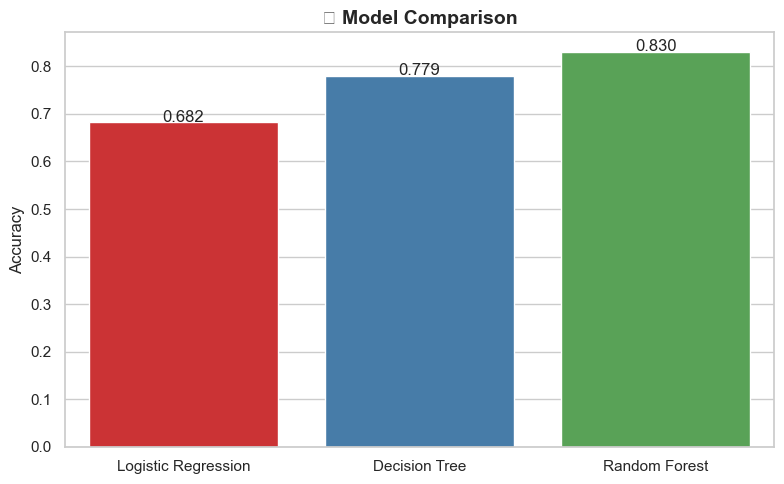

In [194]:
# ===================== 📊 MODEL COMPARISON =====================

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracies, palette='Set1')

plt.title("📊 Model Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")

# Add labels
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()


# ===================== END =====================